In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Mon Mar  9 16:34:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/Pneumonia_Project/chest_xray"

print(os.listdir(DATASET_PATH))

['train', 'test', 'val']


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [ ]:
categories = ["NORMAL", "PNEUMONIA"]

X_train = []
y_train = []

for category in categories:
    folder = os.path.join(DATASET_PATH, "train", category)
    label = categories.index(category)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        # Skip non-image files like .DS_Store
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            print(f"Skipping non-image file: {img_path}")
            continue

        img = preprocess_image(img_path)
        if img is not None:
            X_train.append(img)
            y_train.append(label)
        else:
            print(f"Could not load image: {img_path}")

X_train = np.array(X_train).reshape(-1, 224, 224, 1)
y_train = np.array(y_train)

print("Training data shape:", X_train.shape)

Skipping non-image file: /content/drive/MyDrive/Pneumonia_Project/chest_xray/train/NORMAL/.DS_Store
Skipping non-image file: /content/drive/MyDrive/Pneumonia_Project/chest_xray/train/PNEUMONIA/.DS_Store
Training data shape: (5216, 224, 224, 1)


In [ ]:
X_test = []
y_test = []

for category in categories:
    folder = os.path.join(DATASET_PATH, "test", category)
    label = categories.index(category)

    for img_name in os.listdir(folder):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = os.path.join(folder, img_name)
        img = preprocess_image(img_path)

        if img is not None:
            X_test.append(img)
            y_test.append(label)

X_test = np.array(X_test).reshape(-1, 224, 224, 1)
y_test = np.array(y_test)

print("Test data shape:", X_test.shape)

Test data shape: (624, 224, 224, 1)


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(GlobalAveragePooling2D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,993 (394.50 KB)

 Trainable params: 100,993 (394.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.6642 - loss: 0.6463 - val_accuracy: 0.9684 - val_loss: 0.3987
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7511 - loss: 0.4972 - val_accuracy: 0.9176 - val_loss: 0.2258
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8208 - loss: 0.3897 - val_accuracy: 0.8726 - val_loss: 0.2338
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8474 - loss: 0.3517 - val_accuracy: 0.8678 - val_loss: 0.2402
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8595 - loss: 0.3274 - val_accuracy: 0.8889 - val_loss: 0.2144
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8753 - loss: 0.2889 - val_accuracy: 0.7826 - val_loss: 0.3784
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.8791 - loss: 0.2872 - val_accuracy: 0.8132 - val_loss: 0.3443
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8892 - loss: 0.2708 - val_ac

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5094 - loss: 1.4561
Test Accuracy: 0.7339743375778198


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Confusion Matrix:
[[ 72 162]
 [  4 386]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.31      0.46       234
           1       0.70      0.99      0.82       390

    accuracy                           0.73       624
   macro avg       0.83      0.65      0.64       624
weighted avg       0.80      0.73      0.69       624



In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.8869 - loss: 0.2747 - val_accuracy: 0.9377 - val_loss: 0.1341
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8933 - loss: 0.2627 - val_accuracy: 0.7471 - val_loss: 0.6907
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.8913 - loss: 0.2752 - val_accuracy: 0.9502 - val_loss: 0.1164
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8904 - loss: 0.2766 - val_accuracy: 0.9023 - val_loss: 0.2122
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9034 - loss: 0.2313 - val_accuracy: 0.8170 - val_loss: 0.5294
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9008 - loss: 0.2291 - val_accuracy: 0.9004 - val_loss: 0.2399
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9077 - loss: 0.2248 - val_accuracy: 0.8563 - val_loss: 0.3395
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9071 - loss: 0.2193 - val_ac

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5846 - loss: 1.1473
Test Accuracy: 0.7580128312110901


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[109 125]
 [ 26 364]]
              precision    recall  f1-score   support

           0       0.81      0.47      0.59       234
           1       0.74      0.93      0.83       390

    accuracy                           0.76       624
   macro avg       0.78      0.70      0.71       624
weighted avg       0.77      0.76      0.74       624



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "/train",
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "/train",
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 586ms/step - accuracy: 0.8292 - loss: 0.3932 - val_accuracy: 0.8677 - val_loss: 0.3012
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 519ms/step - accuracy: 0.8521 - loss: 0.3596 - val_accuracy: 0.8380 - val_loss: 0.4019
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 530ms/step - accuracy: 0.8788 - loss: 0.2804 - val_accuracy: 0.8380 - val_loss: 0.3448
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 526ms/step - accuracy: 0.8784 - loss: 0.2852 - val_accuracy: 0.7200 - val_loss: 0.5721
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 517ms/step - accuracy: 0.8785 - loss: 0.2634 - val_accuracy: 0.7919 - val_loss: 0.4429
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 516ms/step - accuracy: 0.8917 - loss: 0.2835 - val_accuracy: 0.8984 - val_loss: 0.2299
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 519ms/step - accuracy: 0.8855 - loss: 0.2830 - val_accuracy: 0.8447 - val_loss: 0.3419
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 518ms/step - accuracy: 0.8821 - loss: 0

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

DATASET_PATH = "/content/drive/MyDrive/Pneumonia_Project/chest_xray"

test_dir_path = os.path.join(DATASET_PATH, "test")
print(f"Attempting to access test directory: {test_dir_path}")

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir_path,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

Attempting to access test directory: /content/drive/MyDrive/Pneumonia_Project/chest_xray/test
Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.8511 - loss: 0.3736
Test Accuracy: 0.7900640964508057


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Getting started.pdf', 'GDS-Downloader', 'Screenshot_20200724-172744_Gallery.jpg', 'Classroom', 'To-do list (1).gsheet', 'Resume (2).gdoc', 'DBMS.gdoc', 'Questions.gdoc', 'To-do list.gsheet', 'AryanMishraResume.pdf', 'Resume ', 'Resume (1).gdoc', 'AryanMishra_Resume.pdf', 'Google AI Studio', 'Resume.gdoc', 'Pneumonia_Project', 'Colab Notebooks', 'Aryan_Mishra_Final_Resume (3) (1).pdf', 'aryan_resume.pdf']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Pneumonia_Project"))

['chest_xray']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Pneumonia_Project/chest_xray"))

['train', 'test', 'val']


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Pneumonia_Project/chest_xray"

In [ ]:
test_dir_path = os.path.join(DATASET_PATH, "test")
print("Test directory exists:", os.path.exists(test_dir_path))

Test directory exists: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.path.exists("/content/drive/MyDrive/Pneumonia_Project/chest_xray/test")

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Pneumonia_Project/chest_xray"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "test"),
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.8511 - loss: 0.3736
Test Accuracy: 0.7900640964508057


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
color_mode='rgb'

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

DATASET_PATH = "/content/drive/MyDrive/Pneumonia_Project/chest_xray"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "train"),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "train"),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    subset='validation'
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.7783 - loss: 0.4576 - val_accuracy: 0.9358 - val_loss: 0.1881
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 877ms/step - accuracy: 0.9210 - loss: 0.1990 - val_accuracy: 0.9559 - val_loss: 0.1515
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 870ms/step - accuracy: 0.9254 - loss: 0.1789 - val_accuracy: 0.9386 - val_loss: 0.1571
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 875ms/step - accuracy: 0.9465 - loss: 0.1418 - val_accuracy: 0.9434 - val_loss: 0.1358
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 884ms/step - accuracy: 0.9465 - loss: 0.1435 - val_accuracy: 0.9616 - val_loss: 0.1121
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 118s 903ms/step - accuracy: 0.9580 - loss: 0.1160 - val_accuracy: 0.9578 - val_loss: 0.1157
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 955ms/step - accuracy: 0.9548 - loss: 0.1185 - val_accuracy: 0.9616 - val_loss: 0.1070
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 962ms/step - accuracy: 0.9613 - lo

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "test"),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 958ms/step - accuracy: 0.8010 - loss: 0.4615
Test Accuracy: 0.875


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_generator.classes, y_pred))
print(classification_report(test_generator.classes, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 615ms/step
[[163  71]
 [  7 383]]
              precision    recall  f1-score   support

           0       0.96      0.70      0.81       234
           1       0.84      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



In [ ]:
# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Keep earlier layers frozen
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9175 - loss: 0.2015 - val_accuracy: 0.9626 - val_loss: 0.1009
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9493 - loss: 0.1390 - val_accuracy: 0.9578 - val_loss: 0.0976
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9515 - loss: 0.1261 - val_accuracy: 0.9607 - val_loss: 0.0979
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 998ms/step - accuracy: 0.9660 - loss: 0.0902 - val_accuracy: 0.9703 - val_loss: 0.0795
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9633 - loss: 0.0951 - val_accuracy: 0.9655 - val_loss: 0.0830


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Fine-Tuned Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 575ms/step - accuracy: 0.7475 - loss: 0.8703
Fine-Tuned Test Accuracy: 0.8493589758872986


In [ ]:
import random
import numpy as np

# Search ranges
LR_RANGE = [1e-5, 5e-5, 1e-4]
DROPOUT_RANGE = [0.3, 0.4, 0.5]
DENSE_RANGE = [64, 128, 256]
UNFREEZE_RANGE = [0, 10, 20, 30]

POPULATION_SIZE = 6
GENERATIONS = 3
MUTATION_RATE = 0.2

In [ ]:
def create_individual():
    return {
        "lr": random.choice(LR_RANGE),
        "dropout": random.choice(DROPOUT_RANGE),
        "dense": random.choice(DENSE_RANGE),
        "unfreeze": random.choice(UNFREEZE_RANGE)
    }

def create_population():
    return [create_individual() for _ in range(POPULATION_SIZE)]

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(params):

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze all layers first
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last N layers
    if params["unfreeze"] > 0:
        for layer in base_model.layers[-params["unfreeze"]:]:
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(params["dense"], activation='relu')(x)
    x = Dropout(params["dropout"])(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=params["lr"]),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def evaluate_individual(params):

    model = build_model(params)

    history = model.fit(
        train_generator,
        epochs=3,
        validation_data=val_generator,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])

    return val_acc

In [ ]:
def tournament_selection(population, scores):
    selected = random.sample(list(zip(population, scores)), 2)
    selected.sort(key=lambda x: x[1], reverse=True)
    return selected[0][0]

In [ ]:
def crossover(parent1, parent2):
    child = {}
    for key in parent1:
        child[key] = random.choice([parent1[key], parent2[key]])
    return child

In [ ]:
def mutate(individual):
    if random.random() < MUTATION_RATE:
        individual["lr"] = random.choice(LR_RANGE)
    if random.random() < MUTATION_RATE:
        individual["dropout"] = random.choice(DROPOUT_RANGE)
    if random.random() < MUTATION_RATE:
        individual["dense"] = random.choice(DENSE_RANGE)
    if random.random() < MUTATION_RATE:
        individual["unfreeze"] = random.choice(UNFREEZE_RANGE)
    return individual

In [ ]:
import random
import numpy as np

LR_RANGE = [1e-5, 5e-5, 1e-4]
DROPOUT_RANGE = [0.3, 0.4, 0.5]
DENSE_RANGE = [64, 128, 256]
UNFREEZE_RANGE = [0, 10, 20, 30]

POPULATION_SIZE = 6
GENERATIONS = 3
MUTATION_RATE = 0.2

In [ ]:
def create_individual():
    return {
        "lr": random.choice(LR_RANGE),
        "dropout": random.choice(DROPOUT_RANGE),
        "dense": random.choice(DENSE_RANGE),
        "unfreeze": random.choice(UNFREEZE_RANGE)
    }

In [ ]:
def create_population():
    return [create_individual() for _ in range(POPULATION_SIZE)]

In [ ]:
def tournament_selection(population, scores):
    selected = random.sample(list(zip(population, scores)), 2)
    selected.sort(key=lambda x: x[1], reverse=True)
    return selected[0][0]

In [ ]:
def crossover(parent1, parent2):
    child = {}
    for key in parent1:
        child[key] = random.choice([parent1[key], parent2[key]])
    return child

In [ ]:
def mutate(individual):

    if random.random() < MUTATION_RATE:
        individual["lr"] = random.choice(LR_RANGE)

    if random.random() < MUTATION_RATE:
        individual["dropout"] = random.choice(DROPOUT_RANGE)

    if random.random() < MUTATION_RATE:
        individual["dense"] = random.choice(DENSE_RANGE)

    if random.random() < MUTATION_RATE:
        individual["unfreeze"] = random.choice(UNFREEZE_RANGE)

    return individual

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(params):

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze layers
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last N layers (GA parameter)
    if params["unfreeze"] > 0:
        for layer in base_model.layers[-params["unfreeze"]:]:
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(params["dense"], activation='relu')(x)
    x = Dropout(params["dropout"])(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=params["lr"]),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def evaluate_individual(params):

    model = build_model(params)

    history = model.fit(
        train_generator,
        epochs=2,                # keep small for GA speed
        validation_data=val_generator,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])

    return val_acc

In [ ]:
population = create_population()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Dataset path (CHANGE if your folder location is different)
DATASET_PATH = "/content/drive/MyDrive/Pneumonia_Project/chest_xray"

IMG_SIZE = 224
BATCH_SIZE = 16

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation & Test preprocessing
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
population = create_population()

for generation in range(GENERATIONS):

    print(f"\nGeneration {generation+1}")

    scores = []

    for individual in population:
        print("Testing:", individual)
        score = evaluate_individual(individual)
        scores.append(score)
        print("Validation Accuracy:", score)

    paired = list(zip(scores, population))
    paired.sort(key=lambda x: x[0], reverse=True)

    sorted_population = [x[1] for x in paired]
    sorted_scores = [x[0] for x in paired]

    # Elitism
    population = sorted_population[:2]

    while len(population) < POPULATION_SIZE:

        parent1 = tournament_selection(sorted_population, sorted_scores)
        parent2 = tournament_selection(sorted_population, sorted_scores)

        child = crossover(parent1, parent2)
        child = mutate(child)

        population.append(child)

best_model_params = population[0]

print("Best Parameters Found:", best_model_params)


Generation 1
Testing: {'lr': 0.0001, 'dropout': 0.5, 'dense': 128, 'unfreeze': 10}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Validation Accuracy: 0.5
Testing: {'lr': 1e-05, 'dropout': 0.4, 'dense': 256, 'unfreeze': 0}
Validation Accuracy: 0.8125
Testing: {'lr': 0.0001, 'dropout': 0.3, 'dense': 128, 'unfreeze': 20}
Validation Accuracy: 0.5
Testing: {'lr': 1e-05, 'dropout': 0.4, 'dense': 128, 'unfreeze': 20}
Validation Accuracy: 0.5
Testing: {'lr': 5e-05, 'dropout': 0.5, 'dense': 256, 'unfreeze': 10}
Validation Accuracy: 0.5
Testing: {'lr': 1e-05, 'dropout': 0.5, 'dense': 64, 'unfreeze': 10}
Validation Accuracy: 0.5

Generation 2
Testing: {'lr': 1e-05, 'dropout': 0.4, 'dense': 256, 'unfreeze': 0}
Validation Accuracy: 0.6875
Testing: {'lr': 0.0001, 'dropout': 0.5, 'dense': 128, 'unfreeze': 10}
Validation Accuracy: 0.5
Testing: {'lr': 1e-05, 'dropout': 0.4, 'dense': 256, 'unfreeze': 10}
Validation Accuracy: 0.5
Testing: {'lr': 1e-05, 'dropout': 0.5, 'dense': 256, 'unfreeze': 0}
Validation Accuracy: 0.5625
Testing: {'lr': 1e-05, 'dropout': 0.4, 'dense': 64, 'unfreeze': 30}
Validation Accuracy: 0.8125
Testing: {'l

In [ ]:
best_model = build_model(best_model_params)

history = best_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 142s 399ms/step - accuracy: 0.7005 - loss: 0.5717 - val_accuracy: 0.6875 - val_loss: 0.5422
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 124s 381ms/step - accuracy: 0.8426 - loss: 0.3471 - val_accuracy: 0.8125 - val_loss: 0.4679
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 125s 383ms/step - accuracy: 0.8925 - loss: 0.2692 - val_accuracy: 0.8125 - val_loss: 0.4380
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 124s 382ms/step - accuracy: 0.8983 - loss: 0.2402 - val_accuracy: 0.8125 - val_loss: 0.4342
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 126s 386ms/step - accuracy: 0.9102 - loss: 0.2141 - val_accuracy: 0.8125 - val_loss: 0.4311
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 151s 414ms/step - accuracy: 0.9223 - loss: 0.1914 - val_accuracy: 0.8125 - val_loss: 0.4092
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 149s 456ms/step - accuracy: 0.9356 - loss: 0.1684 - val_accuracy: 0.8125 - val_loss: 0.3823
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 149s 456ms/step - accuracy: 0.9203 -

In [ ]:
test_loss, test_accuracy = best_model.evaluate(test_generator)
print("Final Test Accuracy:", test_accuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step - accuracy: 0.7594 - loss: 0.5214
Final Test Accuracy: 0.8605769276618958


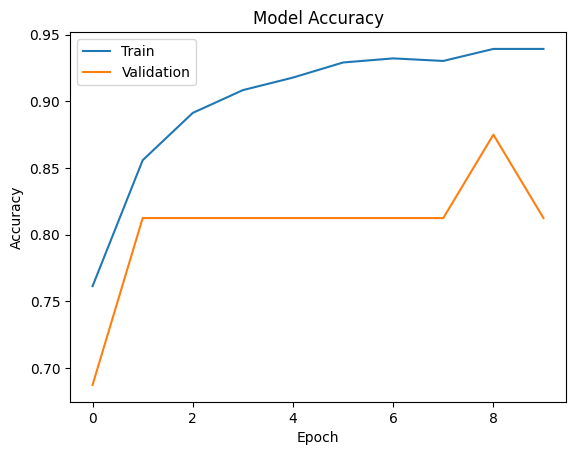

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

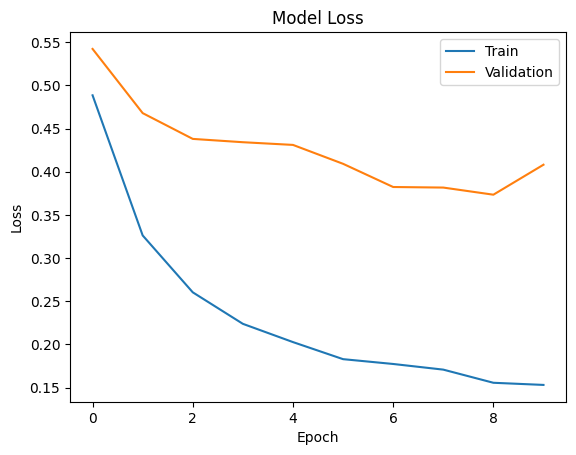

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
model.save("pneumonia_ga_model.h5")

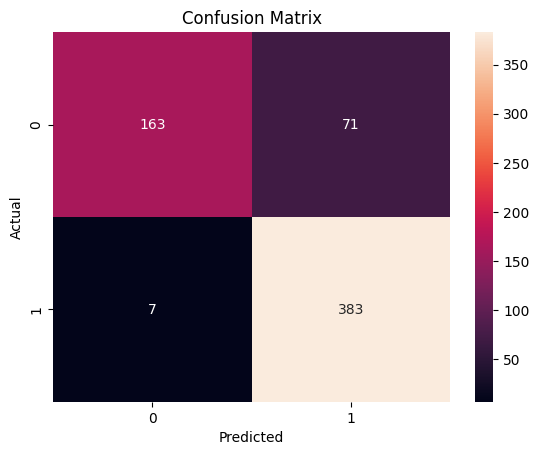

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_generator.classes, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual": test_generator.classes,
    "Predicted": y_pred.flatten()
})

results.to_csv("predictions.csv")

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np

def apply_edge_detection(image):

    # convert RGB → grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # apply Canny edge detector
    edges = cv2.Canny(gray, 50, 150)

    # convert back to 3 channels for CNN
    edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    return edges

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def preprocessing_function(img):
    img = apply_edge_detection(img)
    return img / 255.0

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_function
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_function
)

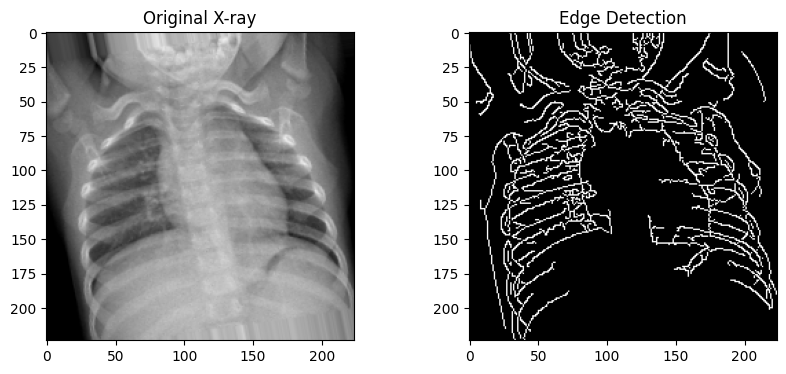

In [ ]:
import matplotlib.pyplot as plt

img, label = train_generator[0]
sample = img[0]

edge = apply_edge_detection((sample*255).astype(np.uint8))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original X-ray")

plt.subplot(1,2,2)
plt.imshow(edge)
plt.title("Edge Detection")

plt.show()

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 149s 422ms/step - accuracy: 0.9620 - loss: 0.1051 - val_accuracy: 0.7500 - val_loss: 0.5339
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 136s 417ms/step - accuracy: 0.9614 - loss: 0.0932 - val_accuracy: 0.8125 - val_loss: 0.4996
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 133s 409ms/step - accuracy: 0.9711 - loss: 0.0780 - val_accuracy: 0.8125 - val_loss: 0.3647
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 129s 395ms/step - accuracy: 0.9752 - loss: 0.0715 - val_accuracy: 0.8125 - val_loss: 0.4088
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 129s 396ms/step - accuracy: 0.9729 - loss: 0.0730 - val_accuracy: 0.9375 - val_loss: 0.2224
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 129s 396ms/step - accuracy: 0.9729 - loss: 0.0688 - val_accuracy: 0.9375 - val_loss: 0.1758
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 129s 397ms/step - accuracy: 0.9790 - loss: 0.0588 - val_accuracy: 0.9375 - val_loss: 0.1218
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 129s 397ms/step - accuracy: 0.9763 -

In [ ]:
test_loss, test_accuracy = best_model.evaluate(test_generator)
print("Final Test Accuracy:", test_accuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.7594 - loss: 0.5214
Final Test Accuracy: 0.8605769276618958
